In [1]:
import logging
import traceback
import os
import cv2
import numpy as np
import torch
import networkx as nx
import itertools
from itertools import count
from typing import Dict, List, Optional
from lapsolver import solve_dense
from scipy.sparse import csr_matrix
from sknetwork.clustering import Leiden

from dataengine.generator.obstacle.debug_utils import draw_mask, Statistics
from dataengine.generator.obstacle.assignment import assign_segments
from dataengine.generator.obstacle.mask import (
    load_ego_masks,
    remove_ego_body_from_masks,
    remove_overlapped_area,
)

from marsneuralzoo.models.yolo_seg import SegmentationYolo
from marsneuralzoo.models.e2emvm import E2emvm
from marsdataio.dbhelper import (
    extract_image,
    collate_images,
    DbTopic,
    DbHandler,
)
from marsdataio.npyhelper import get_all_cameras_params
from marsdataio.videowriter import VideoWriter
from marsdataio.npyrenderer.renderer import generate_colors
from collections import defaultdict
from dataengine.generator.obstacle.assignment import assign_segments
from dataengine.generator.obstacle.segment_tracker import dfs
from dataengine.generator.obstacle.segment_tracker import CameraTrackingHandler

kj/filesystem-disk-unix.c++:1690: warning: PWD environment variable doesn't match current directory; pwd = /home/mars


In [107]:
img0 = cv2.imread('assets/0.jpeg')
img1 = cv2.imread('assets/1.jpeg')

imgs = [img0, img1]

e2emvm = E2emvm(multiview=False)


Loaded SuperPoint model


In [108]:
import time

# Assume e2emvm and imgs are defined
# Measure time for `extract_features`
start_time = time.time()
torch_imgs, features = e2emvm.extract_features(imgs)
extract_features_time = time.time() - start_time
print(f"Time taken for extract_features: {extract_features_time:.4f} seconds")

# Measure time for the model's forward pass
target_pairs = [(0, 1)]
start_time = time.time()
preds = e2emvm(torch_imgs, features, target_pairs)
forward_pass_time = time.time() - start_time
print(f"Time taken for forward pass: {forward_pass_time:.4f} seconds")



Time taken for extract_features: 0.0251 seconds
Time taken for forward pass: 0.0588 seconds


In [120]:
from marsdataio.os.cache import create_ordered_dict

test_cache = create_ordered_dict('./cache')
test_cache[0] = (torch_imgs, features)
test_cache[1] = (torch_imgs, features)
test_cache[2] = (torch_imgs, features)
test_cache[3] = (torch_imgs, features)
test_cache[4] = (torch_imgs, features)
test_cache[5] = (torch_imgs, features)
test_cache[6] = (torch_imgs, features)



In [112]:
ti , feat = test_cache[0]

In [116]:
preds = e2emvm(ti, feat, target_pairs)
ti[0]

tensor([[[0.3490, 0.3608, 0.3529,  ..., 0.0000, 0.0078, 0.0000],
         [0.3529, 0.3608, 0.3490,  ..., 0.0039, 0.0000, 0.0000],
         [0.3608, 0.3647, 0.3490,  ..., 0.0039, 0.0000, 0.0000],
         ...,
         [0.1922, 0.1882, 0.1961,  ..., 0.2902, 0.2824, 0.2784],
         [0.1922, 0.1922, 0.2000,  ..., 0.3098, 0.3020, 0.2941],
         [0.2000, 0.2000, 0.2118,  ..., 0.3294, 0.3216, 0.3137]]], device='cuda:0')

In [122]:
slice0 = 500
slice1 = 300
features['keypoints'][0] = features['keypoints'][0][:slice0]
features['keypoints'][1] = features['keypoints'][1][:300]
features['scores'][0] = features['scores'][0][:slice0]
features['scores'][1] = features['scores'][1][:300]
features['descriptors'][0] = features['descriptors'][0][:, :slice0]
features['descriptors'][1] = features['descriptors'][1][:, :300]

In [124]:
features['keypoints'][0]

tensor([[590., 141.],
        [564., 122.],
        [ 90., 364.],
        [717., 309.],
        [456., 152.],
        [734., 308.],
        [553., 121.],
        [593.,  89.],
        [390., 225.],
        [566., 216.],
        [445., 176.],
        [817., 148.],
        [361., 175.],
        [491.,  86.],
        [553.,  76.],
        [613., 251.],
        [310., 250.],
        [ 64., 395.],
        [579., 122.],
        [727., 265.],
        [808., 299.],
        [659., 171.],
        [592.,  74.],
        [810., 103.],
        [563., 132.],
        [369., 162.],
        [385., 197.],
        [ 26.,  40.],
        [ 55., 356.],
        [134.,  74.],
        [516., 172.],
        [798.,  69.],
        [335., 292.],
        [490.,  71.],
        [637., 232.],
        [ 76.,  25.],
        [566.,  88.],
        [120., 105.],
        [280., 216.],
        [687., 303.],
        [148.,  73.],
        [405., 167.],
        [640., 244.],
        [135.,  45.],
        [235., 336.],
        [5

In [123]:
features['keypoints'][0].cpu()

tensor([[590., 141.],
        [564., 122.],
        [ 90., 364.],
        [717., 309.],
        [456., 152.],
        [734., 308.],
        [553., 121.],
        [593.,  89.],
        [390., 225.],
        [566., 216.],
        [445., 176.],
        [817., 148.],
        [361., 175.],
        [491.,  86.],
        [553.,  76.],
        [613., 251.],
        [310., 250.],
        [ 64., 395.],
        [579., 122.],
        [727., 265.],
        [808., 299.],
        [659., 171.],
        [592.,  74.],
        [810., 103.],
        [563., 132.],
        [369., 162.],
        [385., 197.],
        [ 26.,  40.],
        [ 55., 356.],
        [134.,  74.],
        [516., 172.],
        [798.,  69.],
        [335., 292.],
        [490.,  71.],
        [637., 232.],
        [ 76.,  25.],
        [566.,  88.],
        [120., 105.],
        [280., 216.],
        [687., 303.],
        [148.,  73.],
        [405., 167.],
        [640., 244.],
        [135.,  45.],
        [235., 336.],
        [5

In [106]:
target_pairs = [(0, 1)]
start_time = time.time()
preds = e2emvm(torch_imgs, features, target_pairs)
forward_pass_time = time.time() - start_time
print(f"Time taken for forward pass: {forward_pass_time:.4f} seconds")

Time taken for forward pass: 0.0252 seconds


In [10]:
target_pairs = [(0, 1)]
preds = e2emvm(torch_imgs, features, target_pairs)

In [14]:
all_matches = preds['matches']

debug0 = img0.copy()
debug1 = img1.copy()

for idx0, idx1 in target_pairs:
    key = f'{idx0}_{idx1}'
    matches = all_matches[f'matches0_{key}'][0].cpu().numpy()
    confs = all_matches[f'conf_scores_{key}'][0, :, 0].cpu().numpy()

    valid_indices = np.flatnonzero((matches >= 0) & (confs >= 0.02))

    kpt_idxs0 = valid_indices
    kpt_idxs1 = matches[valid_indices]

    for idx in kpt_idxs0:
        kpt = features['keypoints'][idx0][idx].cpu().numpy().astype(int)
        cv2.circle(debug0, kpt, 5, (255), -1)
    
    for idx in kpt_idxs1:
        kpt = features['keypoints'][idx1][idx].cpu().numpy().astype(int)
        cv2.circle(debug1, kpt, 5, (255), -1)
import matplotlib.pyplot as plt
plt.figure()
plt.subplot(1,2,1)
plt.imshow(debug0)
plt.subplot(1,2,2)
plt.imshow(debug1)

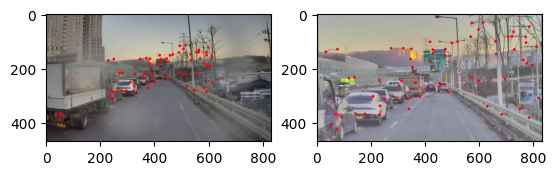

In [31]:


test_cache = create_ordered_dict('./cache')

torch_kpts = features["keypoints"][0].cpu()
test_cache['torch_kpt'] = torch_kpts
test_cache['torch_kpt_gpu'] = features["keypoints"][0]
test_cache['images'] = torch_imgs

# features 
# torch_imgs

In [32]:
loaded_kpt =test_cache['torch_kpt_gpu']

features["keypoints"][0] = loaded_kpt
t_imgs = test_cache['images']
preds = e2emvm(t_imgs, features, target_pairs)



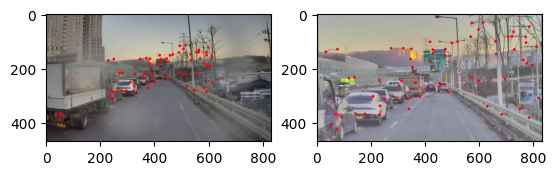

In [33]:

all_matches = preds['matches']

debug0 = img0.copy()
debug1 = img1.copy()

for idx0, idx1 in target_pairs:
    key = f'{idx0}_{idx1}'
    matches = all_matches[f'matches0_{key}'][0].cpu().numpy()
    confs = all_matches[f'conf_scores_{key}'][0, :, 0].cpu().numpy()

    valid_indices = np.flatnonzero((matches >= 0) & (confs >= 0.02))

    kpt_idxs0 = valid_indices
    kpt_idxs1 = matches[valid_indices]

    for idx in kpt_idxs0:
        kpt = features['keypoints'][idx0][idx].cpu().numpy().astype(int)
        cv2.circle(debug0, kpt, 5, (255), -1)
    
    for idx in kpt_idxs1:
        kpt = features['keypoints'][idx1][idx].cpu().numpy().astype(int)
        cv2.circle(debug1, kpt, 5, (255), -1)
import matplotlib.pyplot as plt
plt.figure()
plt.subplot(1,2,1)
plt.imshow(debug0)
plt.subplot(1,2,2)
plt.imshow(debug1)

In [3]:
# torch_imgs  # [N, 1, H, W]

# features['keypoints'][0]  # 1024
# features['keypoints'][1]  # 1024,2

# features['scores'][0].shape # 1024

# features['descriptors'][0].shape # 256, 1024

torch.Size([256, 1024])

In [ ]:

class PointGraph:
    def __init__(self):
        self._cam_to_kpt_to_op_id = defaultdict(lambda: defaultdict(dict))
        self._time_to_op_id_set = defaultdict(set)
        self._op_id_to_op_dict: Dict[int, ObstaclePoint] = {}

    def add_match(
        self,
        time0,
        cam_idx0,
        kpt_idx0,
        uv0,
        nuv0,
        time1,
        cam_idx1,
        kpt_idx1,
        uv1,
        nuv1,
    ):
        op_id0 = self._cam_to_kpt_to_op_id[time0][cam_idx0].get(kpt_idx0, None)
        op_id1 = self._cam_to_kpt_to_op_id[time1][cam_idx1].get(kpt_idx1, None)

        op = None
        if op_id0 is None and op_id1 is None:
            op = ObstaclePoint()
            self._op_id_to_op_dict[op.id] = op

            # op.cam_to_uv.setdefault(time0, {})[cam_idx0] = uv0
            # op.cam_to_nuv.setdefault(time0, {})[cam_idx0] = nuv0
            # op.cam_to_kpt_idx.setdefault(time0, {})[cam_idx0] = kpt_idx0

            # op.cam_to_uv.setdefault(time1, {})[cam_idx1] = uv1
            # op.cam_to_nuv.setdefault(time1, {})[cam_idx1] = nuv1
            # op.cam_to_kpt_idx.setdefault(time1, {})[cam_idx1] = kpt_idx1

            # self._cam_to_kpt_to_op_id[time0][cam_idx0][kpt_idx0] = op.id
            # self._cam_to_kpt_to_op_id[time1][cam_idx1][kpt_idx1] = op.id

        elif op_id0 is not None and op_id1 is None:
            op = self._op_id_to_op_dict[op_id0]

        elif op_id0 is None and op_id1 is not None:
            op = self._op_id_to_op_dict[op_id1]

        else:
            if op_id0 == op_id1:
                op = self._op_id_to_op_dict[op_id0]

            else:
                op0 = self._op_id_to_op_dict[op_id0]
                op1 = self._op_id_to_op_dict[op_id1]

                op = ObstaclePoint()
                self._op_id_to_op_dict[op.id] = op

                for time, cam_idx_to_uv in op0.cam_to_uv.items():
                    op.cam_to_uv.setdefault(time, {}).update(cam_idx_to_uv)

                for time, cam_idx_to_nuv in op0.cam_to_nuv.items():
                    op.cam_to_nuv.setdefault(time, {}).update(cam_idx_to_nuv)

                for time, cam_idx_to_kpt in op0.cam_to_kpt_idx.items():
                    op.cam_to_kpt_idx.setdefault(time, {}).update(
                        cam_idx_to_kpt
                    )
                    self._time_to_op_id_set[time].remove(op0.id)

                for time, cam_idx_to_uv in op1.cam_to_uv.items():
                    op.cam_to_uv.setdefault(time, {}).update(cam_idx_to_uv)

                for time, cam_idx_to_nuv in op1.cam_to_nuv.items():
                    op.cam_to_nuv.setdefault(time, {}).update(cam_idx_to_nuv)

                for time, cam_idx_to_kpt in op1.cam_to_kpt_idx.items():
                    op.cam_to_kpt_idx.setdefault(time, {}).update(
                        cam_idx_to_kpt
                    )
                    self._time_to_op_id_set[time].remove(op1.id)

                for time, cam_idx_to_kpt in op.cam_to_kpt_idx.items():
                    for cam_idx, kpt_idx in cam_idx_to_kpt.items():
                        self._cam_to_kpt_to_op_id[time][cam_idx][
                            kpt_idx
                        ] = op.id

                for time, _ in op.cam_to_kpt_idx.items():
                    self._time_to_op_id_set[time].add(op.id)
                
                del self._op_id_to_op_dict[op0.id]
                del self._op_id_to_op_dict[op1.id]

        op.cam_to_uv.setdefault(time0, {})[cam_idx0] = uv0
        op.cam_to_nuv.setdefault(time0, {})[cam_idx0] = nuv0
        op.cam_to_kpt_idx.setdefault(time0, {})[cam_idx0] = kpt_idx0

        op.cam_to_uv.setdefault(time1, {})[cam_idx1] = uv1
        op.cam_to_nuv.setdefault(time1, {})[cam_idx1] = nuv1
        op.cam_to_kpt_idx.setdefault(time1, {})[cam_idx1] = kpt_idx1

        self._cam_to_kpt_to_op_id[time0][cam_idx0][kpt_idx0] = op.id
        self._cam_to_kpt_to_op_id[time1][cam_idx1][kpt_idx1] = op.id

        self._time_to_op_id_set[time0].add(op.id)
        self._time_to_op_id_set[time1].add(op.id)